# 01 — Functional reference and depth-stability review

Review the saved reference images and depth measurements. This notebook only reads existing files.

In [1]:
# 02 — Load the review tools
from pathlib import Path
from IPython.display import Image, display
from codeants_2pf_hcr.qc_notebooks import QCNotebookConfig, build_qc_stage_inventory, resolve_qc_notebook_context
from codeants_2pf_hcr.plots.qc_functional import load_functional_reference_drift_qc, render_functional_reference_artifacts, render_functional_reference_drift_summary

## 03 — Choose the data to review

Choose the folder that contains the fish and the exact saved run to review. Do not combine files from different runs.

In [2]:
# 04 — Set the fish and saved run
FISH_ID = "L765_f04"
LOCAL_ROOT = Path("/Volumes/dataDrive/dataProcessing/2p_processing")
PIPELINE_ROOT = Path("/Volumes/dataDrive/dataProcessing/2p_processing/_staged_pipeline_runs/20260803T085432Z_first_block_exclusion_remaining/L765_f04")
CONFIG = QCNotebookConfig(fish_id=FISH_ID, local_root=LOCAL_ROOT, pipeline_root=PIPELINE_ROOT)
CONTEXT = resolve_qc_notebook_context(CONFIG)

In [3]:
# 05 — Check that the reference files are available
STAGE_INVENTORY = build_qc_stage_inventory(CONTEXT)
display(STAGE_INVENTORY[STAGE_INVENTORY["stage_name"] == "prepare-functional-reference-stacks"])

,stage_name,stage_root,stage_root_exists,manifest_path,manifest_exists,manifest_status,artifact_count,artifact_exists_count,required_artifacts_exist,artifact_paths
0,prepare-functional-reference-stacks,/Volumes/dataDrive/dataProcessing/2p_processin...,True,/Volumes/dataDrive/dataProcessing/2p_processin...,True,pass,20,20,True,(/Volumes/dataDrive/dataProcessing/2p_processi...


## 06 — Load the saved evidence

Response files are listed only to show whether they are available. They do not decide whether the fish responded.

In [4]:
# 07 — Load the reference and depth-stability results
Z_DRIFT_ROOT = CONTEXT.fish_dir / "03_analysis" / "functional" / "ncc" / "z_drift"
RESPONSE_EVIDENCE_PATHS = [
    CONTEXT.fish_dir / "03_analysis" / "functional" / "qa" / "suite2p_response_bpi_cells_23c.csv",
    CONTEXT.fish_dir / "03_analysis" / "functional" / "qa" / "suite2p_response_bpi_summary_23c.csv",
]
DRIFT_QC = load_functional_reference_drift_qc(
    fish_id=CONTEXT.fish_id,
    functional_reference_manifest_path=CONTEXT.manifest_paths["prepare-functional-reference-stacks"],
    z_drift_root=Z_DRIFT_ROOT,
    response_evidence_paths=RESPONSE_EVIDENCE_PATHS,
)

,plane_label,plane_index,decision,frame_start,source_frame_count,reference_frame_count
0,L765_f04_plane0_mcorrected_flipX,0,excluded_first_selected_tiff_block,1834,5502,3668
1,L765_f04_plane1_mcorrected_flipX,1,excluded_first_selected_tiff_block,1834,5502,3668
2,L765_f04_plane2_mcorrected_flipX,2,excluded_first_selected_tiff_block,1834,5502,3668
3,L765_f04_plane3_mcorrected_flipX,3,excluded_first_selected_tiff_block,1834,5502,3668
4,L765_f04_plane4_mcorrected_flipX,4,excluded_first_selected_tiff_block,1834,5502,3668
5,L765_f04_plane5_mcorrected_flipX,5,excluded_first_selected_tiff_block,1834,5502,3668
6,L765_f04_plane6_mcorrected_flipX,6,excluded_first_selected_tiff_block,1834,5502,3668
7,L765_f04_plane7_mcorrected_flipX,7,excluded_first_selected_tiff_block,1834,5502,3668
8,L765_f04_plane8_mcorrected_flipX,8,excluded_first_selected_tiff_block,1834,5502,3668
9,L765_f04_plane9_mcorrected_flipX,9,excluded_first_selected_tiff_block,1834,5502,3668


,fish_id,session,plane_count,interval_count,consensus_change_slices,consensus_slope_slices_per_interval,exact_order_permutation_p,same_direction_plane_fraction,max_plane_abs_change_slices,initial_step_slices,post_initial_change_slices,post_initial_slope_slices_per_interval,post_initial_exact_order_permutation_p,post_initial_same_direction_plane_fraction,post_initial_plane_change_iqr_slices,post_initial_range_slices,full_consensus_range_slices,evidence_tier
0,L765_f04,r1,5,6,0.135756,0.018887,0.079057,0.8,0.361374,0.124134,0.011621,0.003592,0.471074,0.8,0.030093,0.031767,0.135756,stable_no_drift_evidence
1,L765_f04,r2,5,6,-1.000456,-0.201120,0.006935,1.0,1.279968,0.043785,-1.044241,-0.239552,0.024793,1.0,0.170112,1.044241,1.044241,stable_no_drift_evidence


,name,path,available
0,suite2p_response_bpi_cells_23c.csv,/Volumes/dataDrive/dataProcessing/2p_processin...,False
1,suite2p_response_bpi_summary_23c.csv,/Volumes/dataDrive/dataProcessing/2p_processin...,False


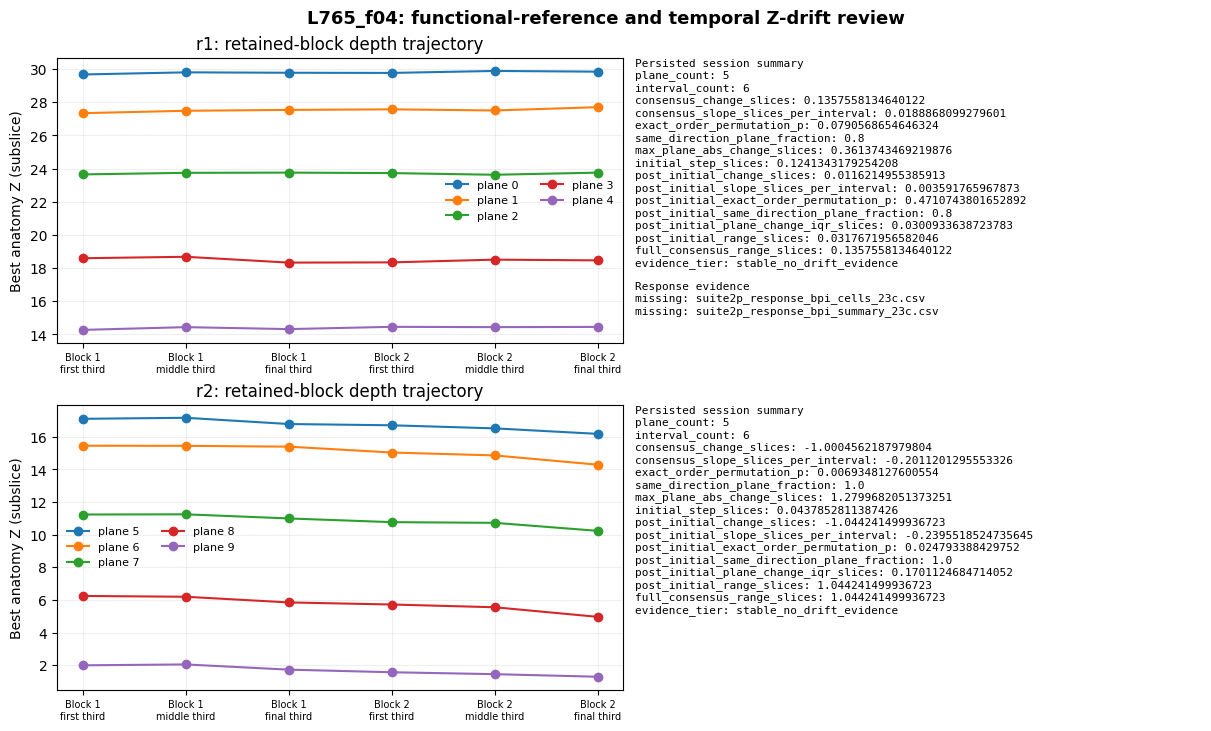

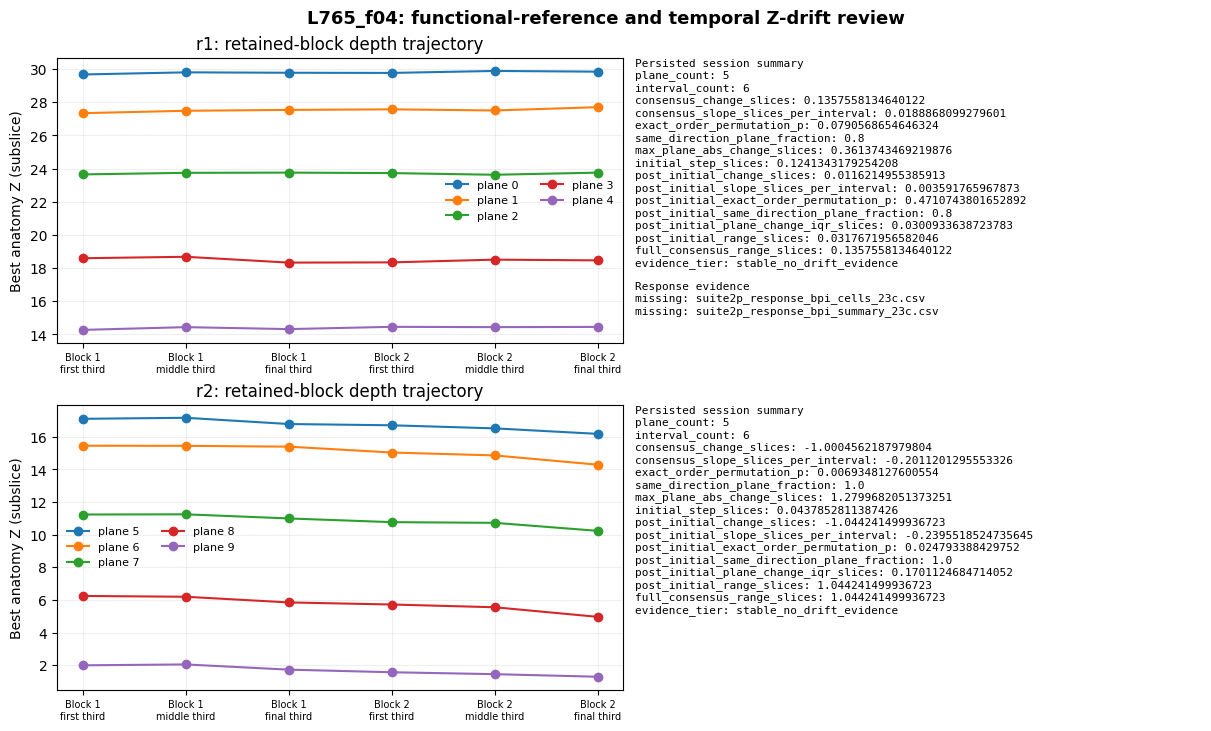

In [5]:
# 08 — Review the data tables
display(DRIFT_QC["block0_provenance"])
display(DRIFT_QC["session_summary"])
display(DRIFT_QC["response_evidence"])
render_functional_reference_drift_summary(DRIFT_QC)

## 09 — View the saved reference images

These are the reference images used for this run.

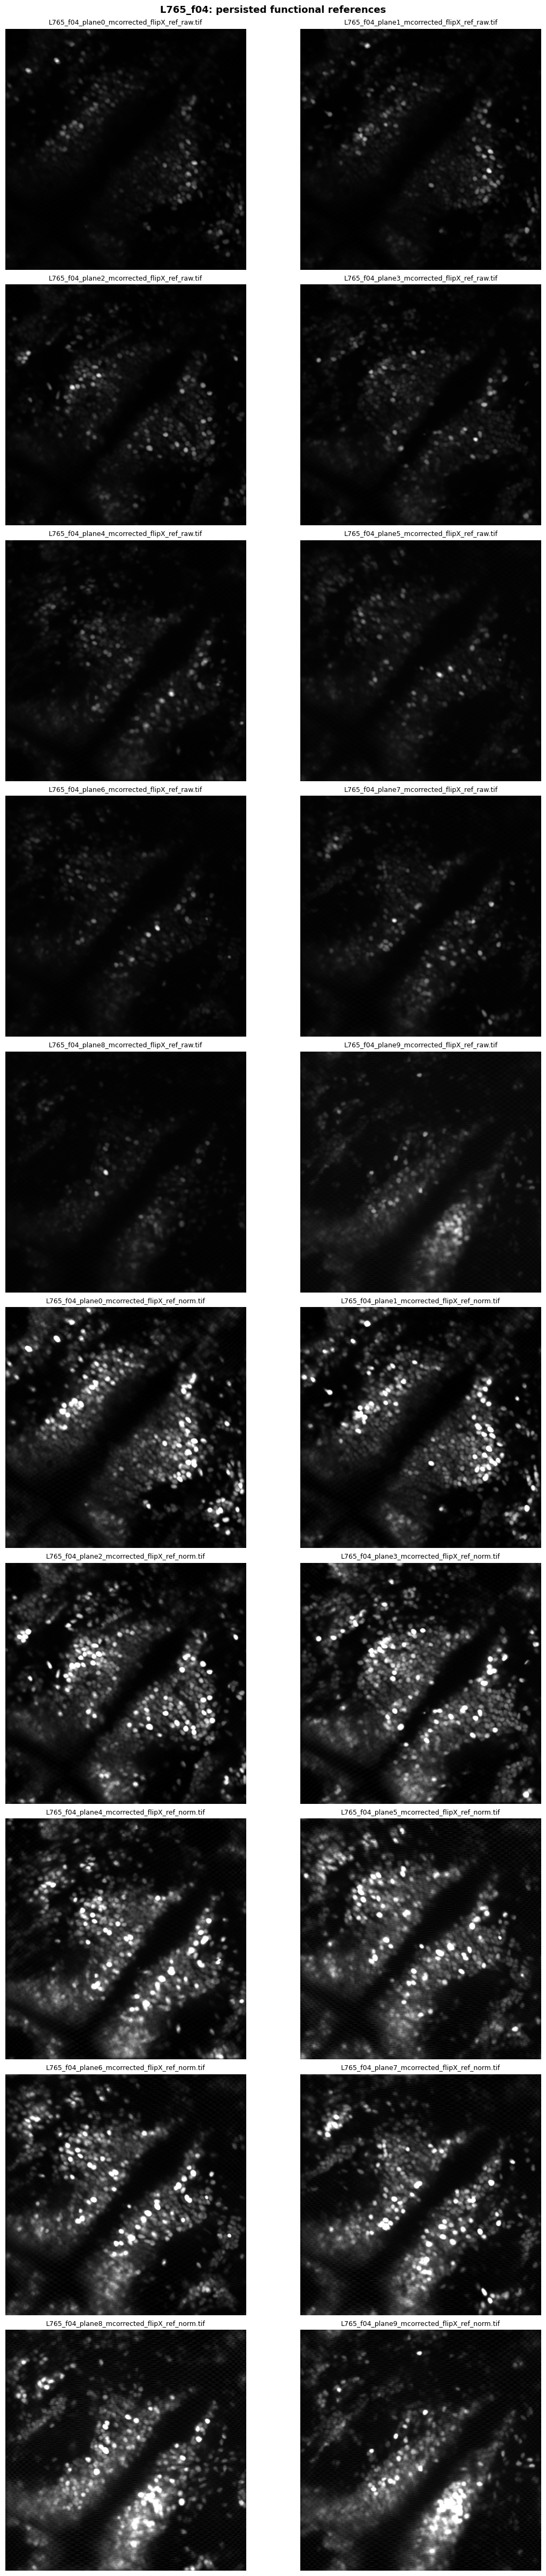

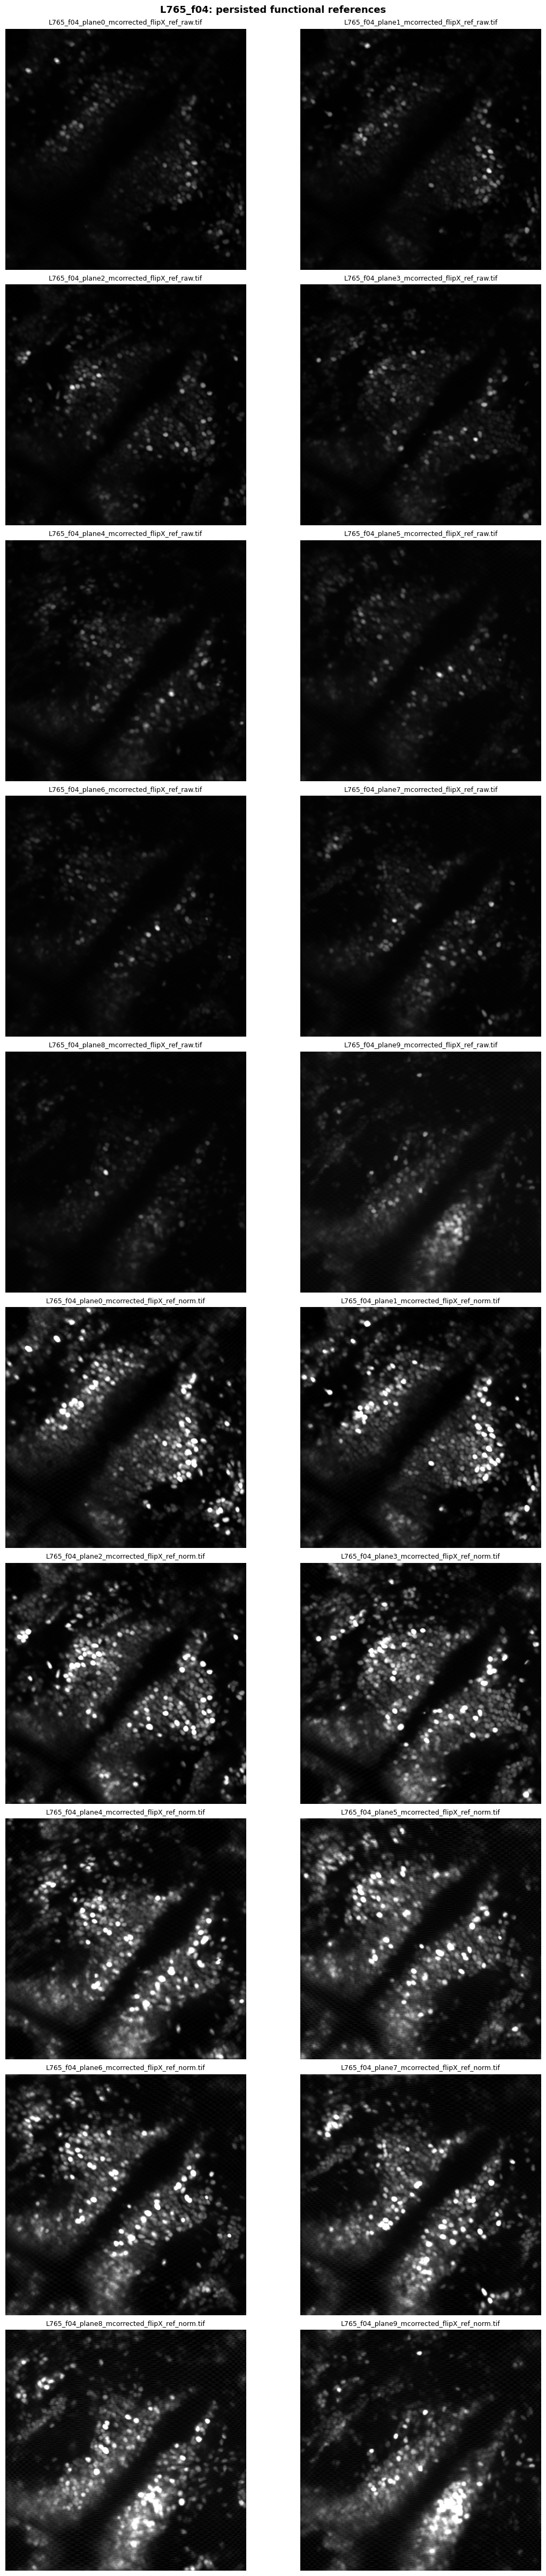

In [6]:
# 10 — Display the reference images
render_functional_reference_artifacts(DRIFT_QC)

## 11 — Inspect depth stability

Look at both the depth track and the matching profiles before deciding whether each session stayed stable.

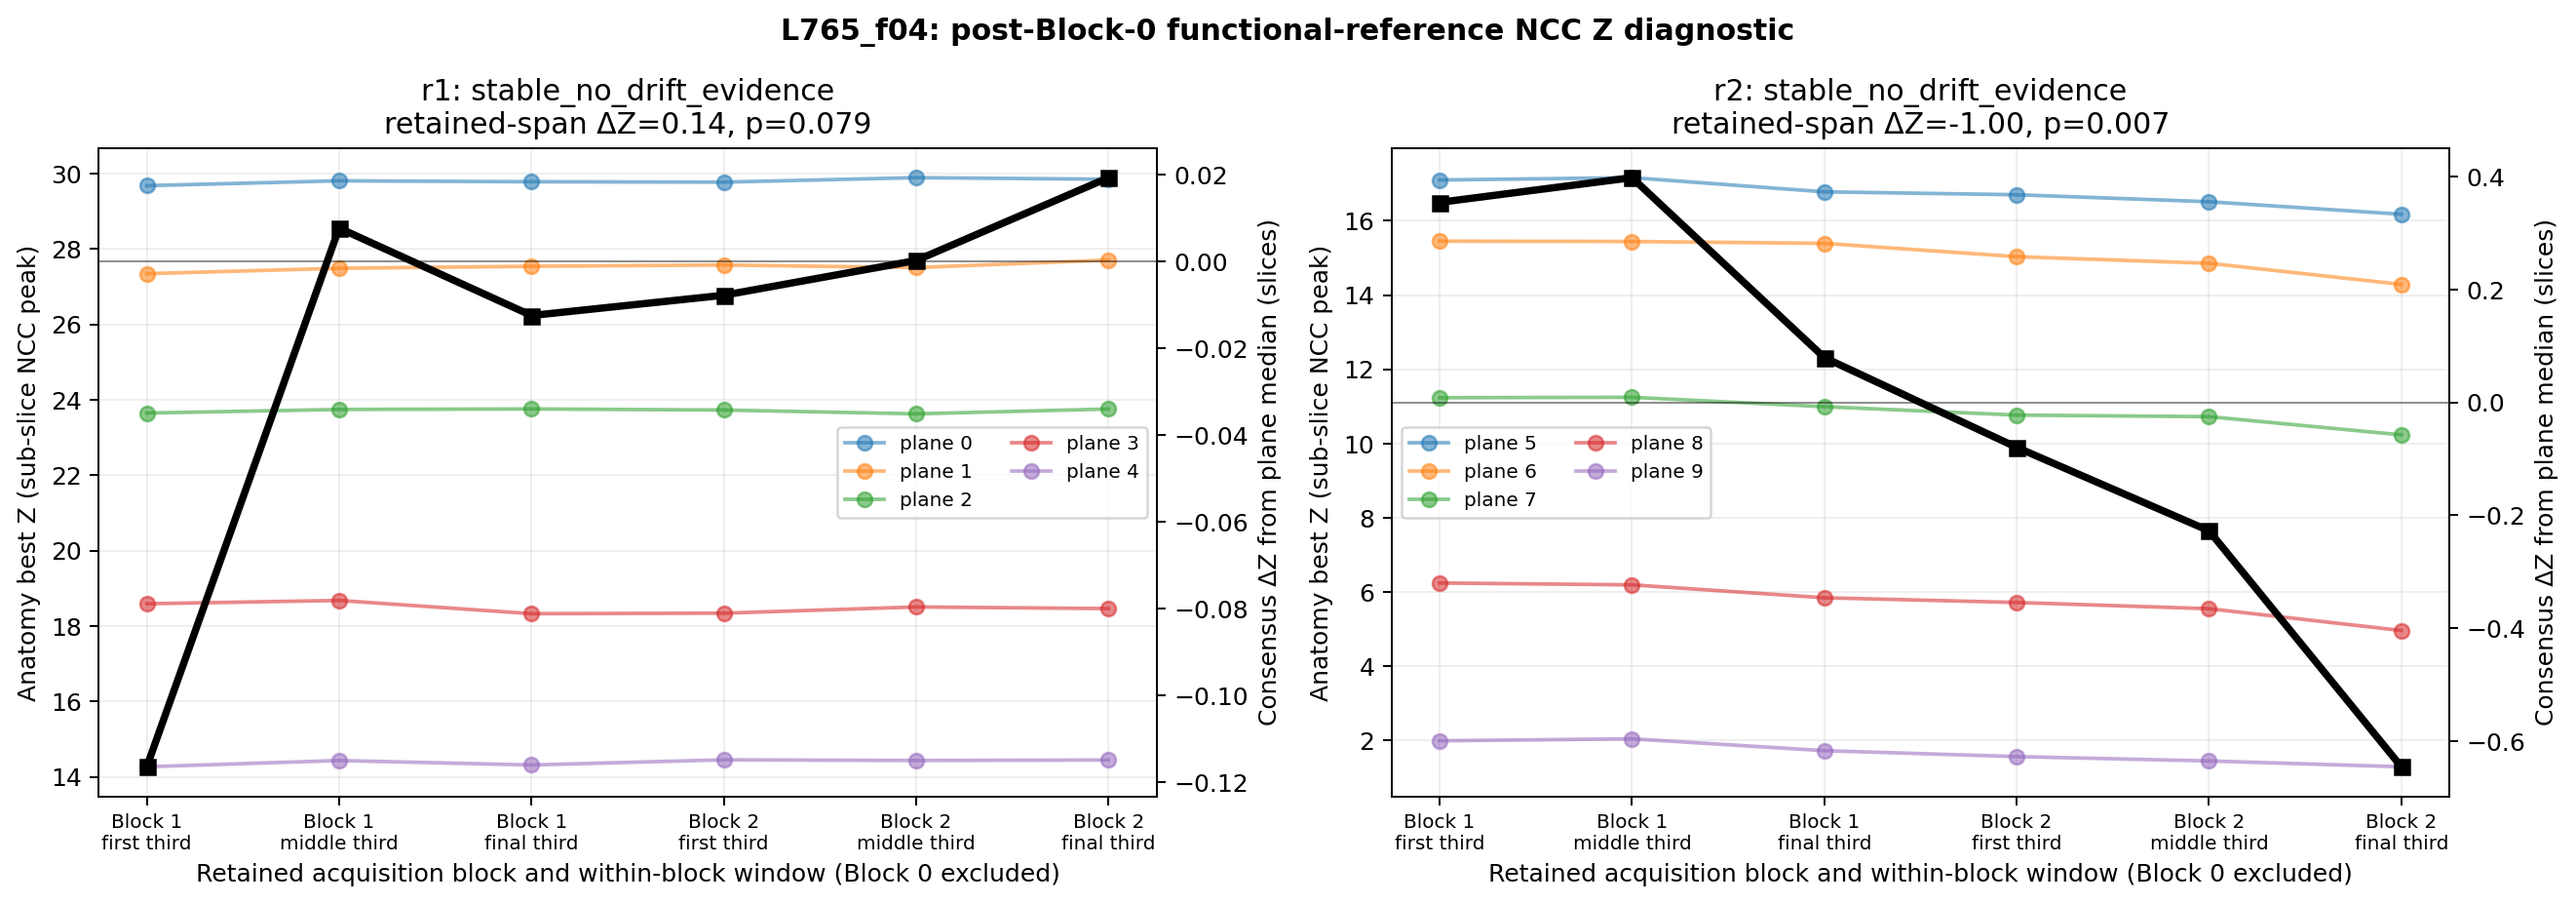

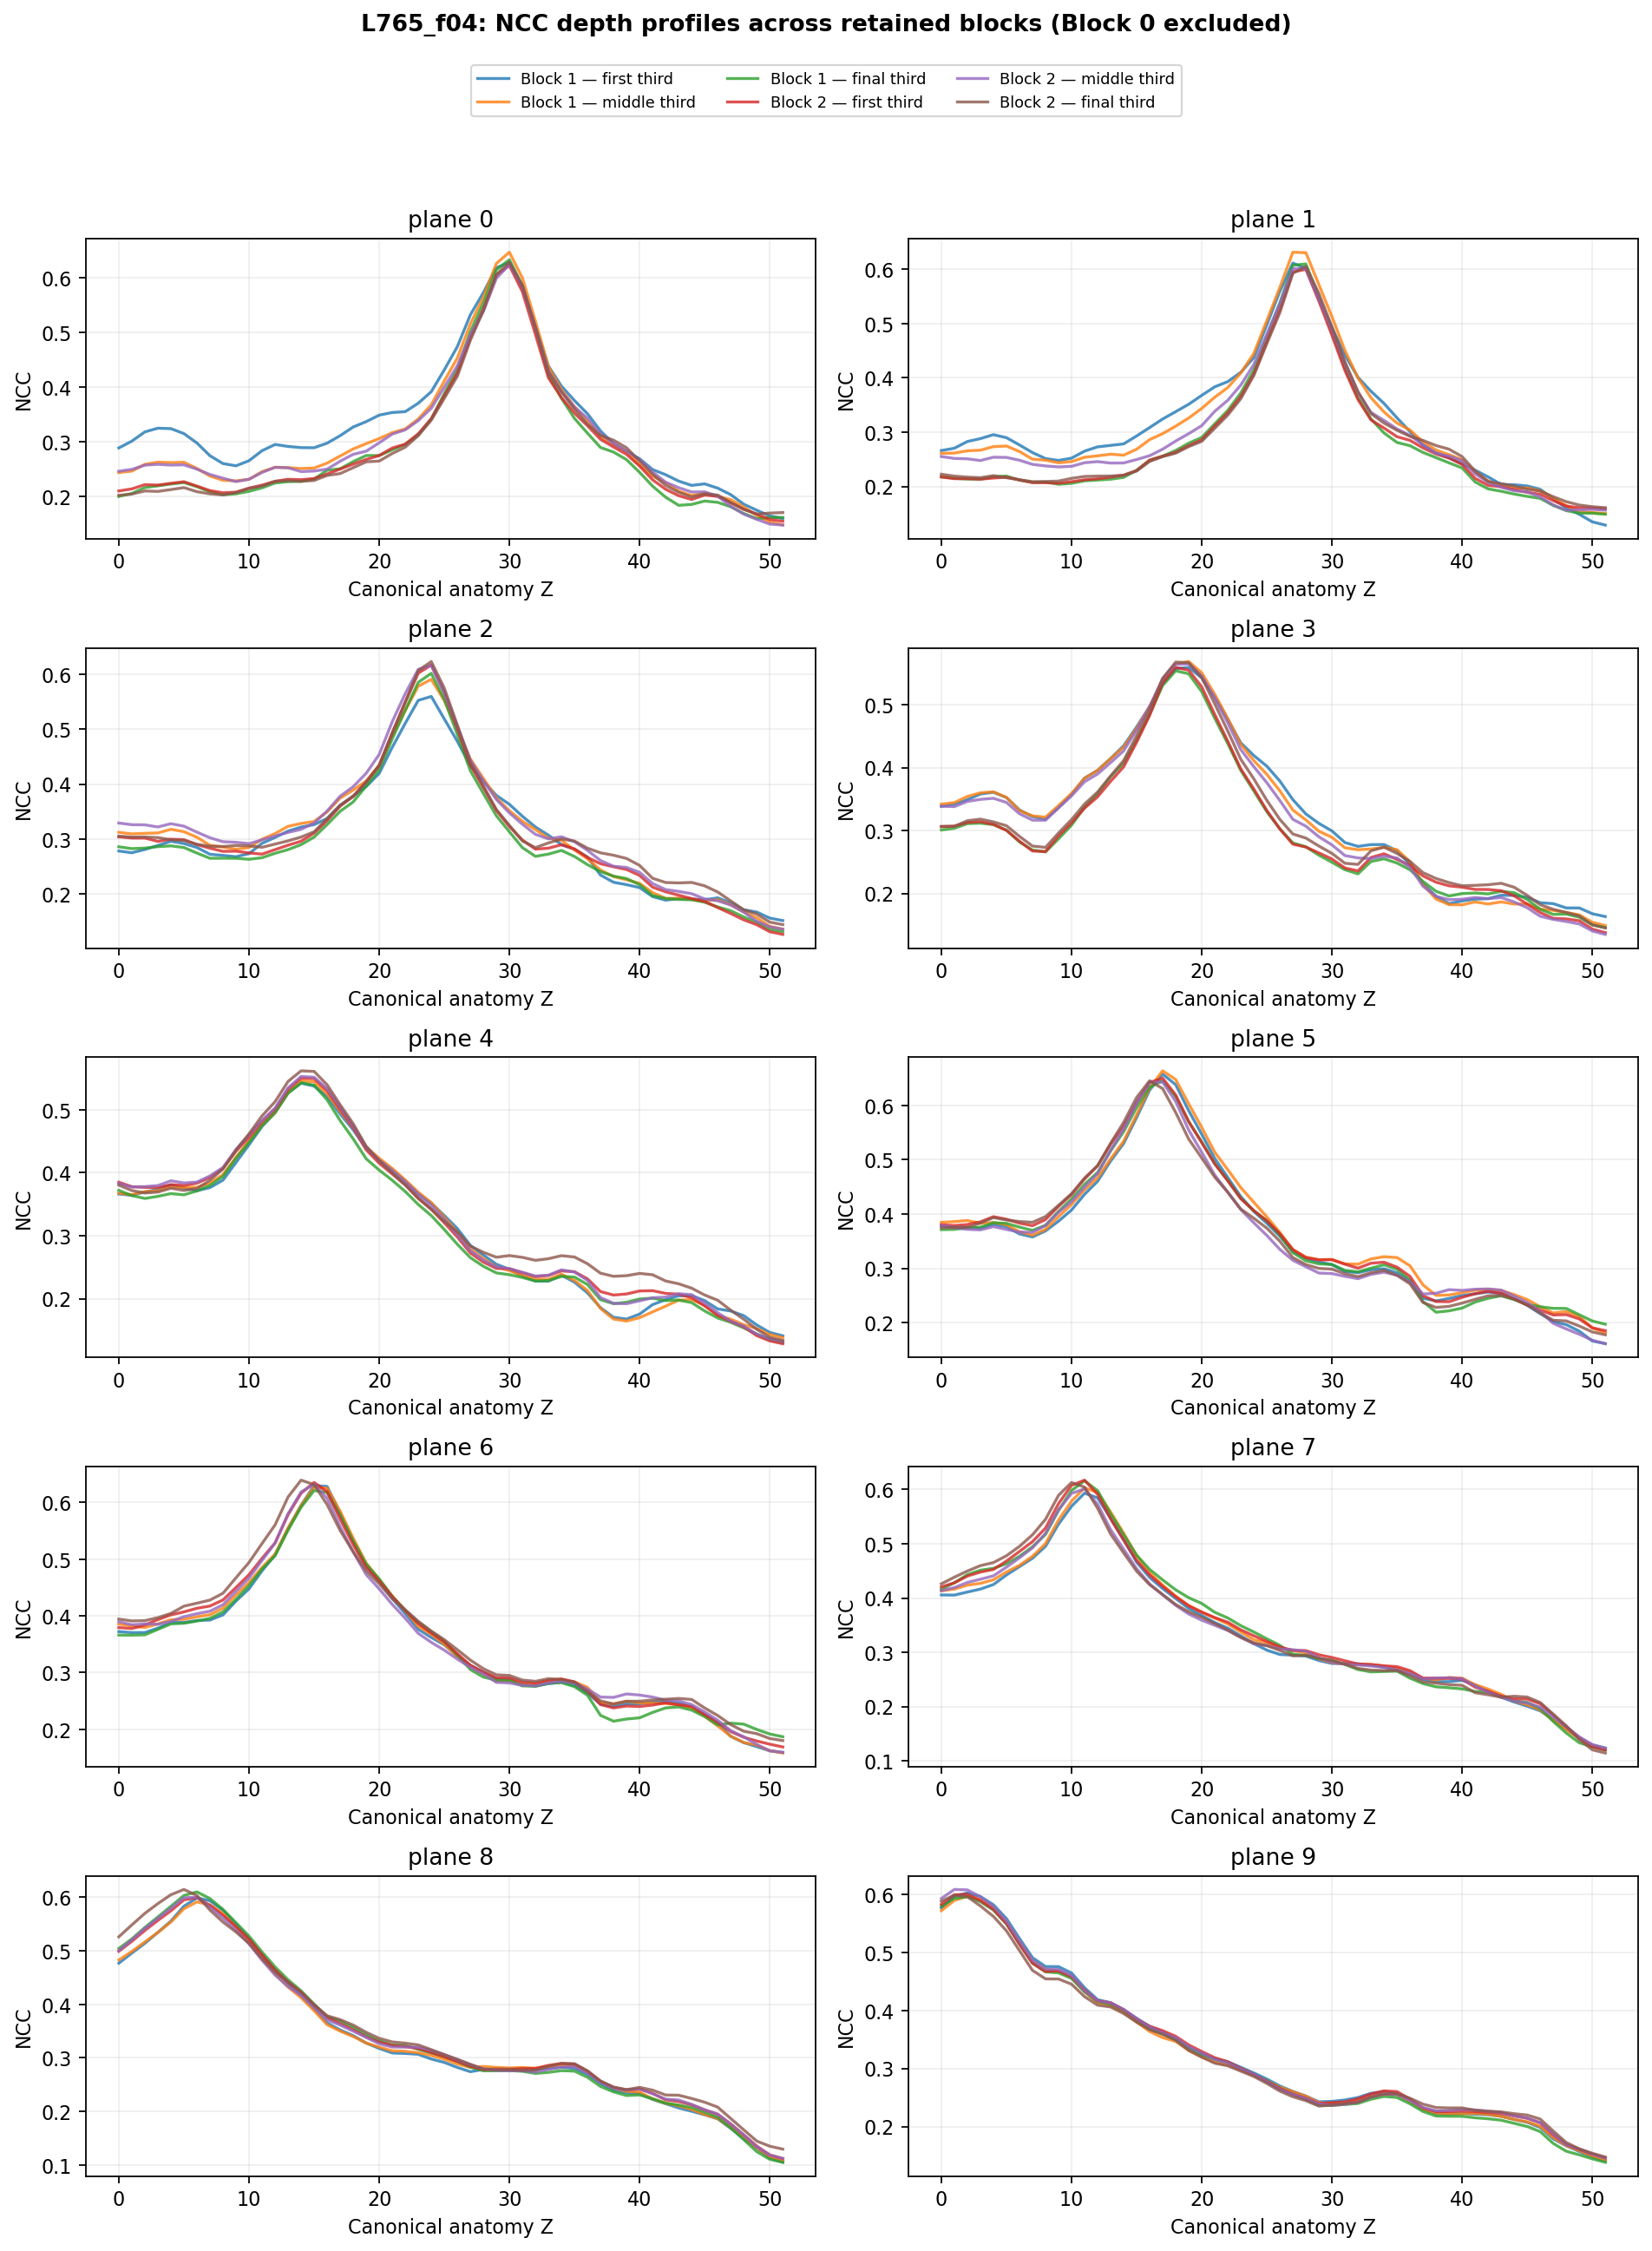

In [7]:
# 12 — Display the depth figures
display(Image(filename=str(DRIFT_QC["trajectory_png"])))
display(Image(filename=str(DRIFT_QC["profile_png"])))

## 13 — Record the review decision

Use the terms `stable`, `computed_unreviewed`, `material_drift`, or `blocked`. Record an accepted decision in the lab logbook.

In [8]:
# 14 — Fill in the decision for discussion or logbook entry
REVIEWER = ""
DECISION = "computed_unreviewed"
NOTES = ""
REVIEW_DECISION = {"fish_id": FISH_ID, "reviewer": REVIEWER, "decision": DECISION, "notes": NOTES}
REVIEW_DECISION

{'fish_id': 'L765_f04',
 'reviewer': '',
 'decision': 'computed_unreviewed',
 'notes': ''}